# 09 — Track A: zero-temp DSPy causal agent (OpenRouter / claude-sonnet-4.6)

Monthly walk-forward rebalance, 2019-01 → 2024-12.

At each rebalance date t:
1. Build a macro state vector from the last month-end of `build_macro_panel` before t: `{cpi_yoy_z, t10y2y_z, hy_oas_z}`.
2. Build an anonymized asset snapshot — letters + category + trailing_12m_return + trailing_vol_ann.
3. Ask the agent for Black-Litterman views (`asset_long`, `asset_short`, expected excess annualized, confidence).
4. Convert views → (P, Q) with Q confidence-gated (`Q = expected × confidence / 252`).
5. Base weights = HRP-CVaR with BIL pinned at 25%. BL posterior with Utility objective. Final = 0.7·HRP + 0.3·BL, renormalized.

Lookahead hygiene:
- Agent sees only rounded z-scores + pseudo letters. No dates, no tickers.
- Responses cached on the hash of (rounded macro state, asset snapshot, prompt version). First run calls the LLM; reruns are free.
- DSPy `temperature=0` → reproducible.

In [1]:
%load_ext autoreload
%autoreload 2

import sys
import warnings
from pathlib import Path

warnings.filterwarnings("ignore")
sys.path.insert(0, str(Path.cwd().parent))

import json

import numpy as np
import pandas as pd

import macro_framework as mf

pd.set_option("display.width", 200)

## 1. Setup

In [2]:
INIT_CASH = 10_000.0
SIM_START = "2019-01-01"
SIM_END   = "2024-12-31"
LOOKBACK_DAYS = 756
TILT = 0.30

spec = pd.read_parquet(Path.cwd().parent / "data" / "portfolio_ssr_top_per_category.parquet")
SYMBOLS = spec["symbol"].tolist()
asset_map = mf.AssetMap.default()

prices = mf.get_prices(SYMBOLS + ["SPY"], start="2014-01-01", end=SIM_END)
macro_panel = mf.build_macro_panel()
panel_z_cols = ["cpi_yoy_z", "t10y2y_z", "hy_oas_z"]

rebalance_dates = mf.monthly_rebalance_dates(prices, start=SIM_START, end=SIM_END)
print(f"{len(rebalance_dates)} monthly rebalances  {rebalance_dates[0].date()} → {rebalance_dates[-1].date()}")

agent = mf.LlmMacroAgent(asset_map=asset_map)

72 monthly rebalances  2019-01-02 → 2024-12-02


## 2. Track A weight function — records views + reasoning per rebalance

In [3]:
log = {"macro_state": {}, "views": {}, "reasoning": {}, "weights": {}}


def _trailing_vol_ann(returns: pd.Series, window: int = 252) -> float:
    tail = returns.dropna().tail(window)
    return float(tail.std(ddof=1) * np.sqrt(252)) if len(tail) >= 30 else float("nan")


def _trailing_12m_return(prices_col: pd.Series) -> float:
    p = prices_col.dropna()
    if len(p) < 253:
        return float("nan")
    return float(p.iloc[-1] / p.iloc[-253] - 1.0)


def track_a_fn(ctx):
    rb = ctx["rebalance_date"]
    macro_hist = ctx["macro_panel"]
    returns_hist = ctx["returns"]
    prices_hist = ctx["prices"]

    # Base HRP (always computed — agent output augments, never replaces)
    w_hrp = mf.hrp_cvar_weights_with_fixed(returns_hist, {"BIL": 0.25})

    # Latest macro state (month-end z-scores strictly before rebalance)
    macro_z = macro_hist[panel_z_cols].dropna()
    if macro_z.empty:
        log["weights"][rb] = w_hrp.to_dict()
        return w_hrp
    macro_state = macro_z.iloc[-1].to_dict()

    # Anonymized asset snapshot
    asset_snap = []
    for real, pseudo in asset_map.real_to_pseudo.items():
        asset_snap.append({
            "id": pseudo,
            "category": asset_map.categories[pseudo],
            "trailing_12m_return": _trailing_12m_return(prices_hist[real]),
            "trailing_vol_ann":    _trailing_vol_ann(returns_hist[real]),
        })

    views, reasoning = agent.views_for_state(macro_state, asset_snap)
    log["macro_state"][rb] = macro_state
    log["views"][rb] = [v.to_dict() for v in views]
    log["reasoning"][rb] = reasoning

    P, Q = agent.views_to_bl(views, SYMBOLS)
    if P is None:
        log["weights"][rb] = w_hrp.to_dict()
        return w_hrp
    try:
        w_bl = mf.bl_mv_weights(returns_hist, prior_weights=w_hrp, P=P, Q=Q, obj="Utility")
    except Exception as exc:  # noqa: BLE001
        print(f"[track_a @ {rb.date()}] BL failed ({exc!r}); using HRP only")
        log["weights"][rb] = w_hrp.to_dict()
        return w_hrp

    w = (1.0 - TILT) * w_hrp + TILT * w_bl
    w = w / w.sum()
    log["weights"][rb] = w.to_dict()
    return w

## 3. Walk-forward — this makes up to 72 LLM calls on the first run (cached after)

In [4]:
targets = mf.build_walk_forward_targets(
    prices[SYMBOLS],
    rebalance_dates=rebalance_dates,
    weight_fns={"track_a": track_a_fn},
    macro_panel=macro_panel,
    lookback_days=LOOKBACK_DAYS,
)
tgt = targets["track_a"]
print(f"target rows set: {tgt.dropna(how='all').shape[0]} / {len(rebalance_dates)}")

target rows set: 72 / 72


## 4. Inspect agent outputs at 2022 crisis months

In [5]:
for rb in rebalance_dates:
    if pd.Timestamp("2022-01-01") <= rb <= pd.Timestamp("2022-12-31"):
        state = log["macro_state"].get(rb, {})
        views = log["views"].get(rb, [])
        print(f"=== {rb.date()} ===")
        print(f"  state: {state}")
        for v in views:
            print(f"  view:  long={v['asset_long']} short={v['asset_short']} "
                  f"ann={v['expected_excess_annualized']:+.3f} conf={v['confidence']:.2f}")
        print()

=== 2022-01-03 ===
  state: {'cpi_yoy_z': 3.170994984442265, 't10y2y_z': 0.3944610174881134, 'hy_oas_z': -0.9341662189623211}
  view:  long=Asset_C short=Asset_B ann=+0.090 conf=0.52
  view:  long=Asset_C short=Asset_A ann=+0.050 conf=0.38

=== 2022-02-01 ===
  state: {'cpi_yoy_z': 3.084259814936979, 't10y2y_z': -0.018251564909004824, 'hy_oas_z': -0.4315468087630016}
  view:  long=Asset_C short=Asset_B ann=+0.090 conf=0.52
  view:  long=Asset_C short=Asset_D ann=+0.060 conf=0.45

=== 2022-03-01 ===
  state: {'cpi_yoy_z': 3.00118227170346, 't10y2y_z': -0.541288392507874, 'hy_oas_z': -0.30119309643756575}
  view:  long=Asset_C short=Asset_B ann=+0.080 conf=0.55
  view:  long=Asset_C short=Asset_A ann=+0.040 conf=0.40

=== 2022-04-01 ===
  state: {'cpi_yoy_z': 3.030296237468926, 't10y2y_z': -1.3756336244535858, 'hy_oas_z': -0.6095983681817746}
  view:  long=Asset_C short=Asset_B ann=+0.090 conf=0.55
  view:  long=Asset_C short=Asset_A ann=+0.050 conf=0.42

=== 2022-05-02 ===
  state: {'cp

## 5. Target weights evolution

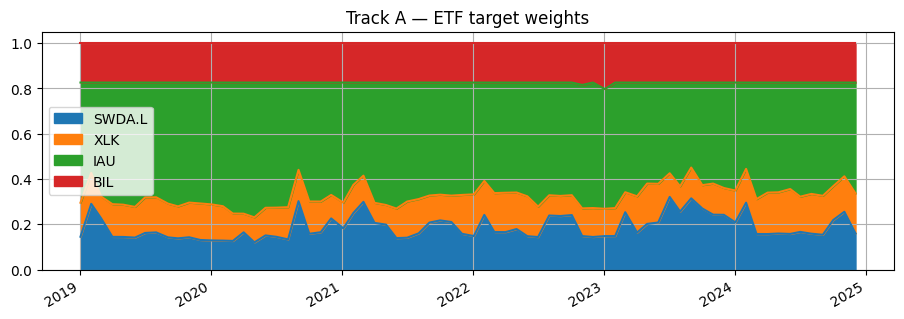

In [6]:
import matplotlib.pyplot as plt

weights_df = pd.DataFrame(log["weights"]).T.sort_index().reindex(columns=SYMBOLS)
weights_df.plot(figsize=(11, 3.5), kind="area", stacked=True, title="Track A — ETF target weights", grid=True);

## 6. Simulate

In [7]:
pf     = mf.run_rebalance_sim(prices[SYMBOLS], tgt, init_cash=INIT_CASH)
spy_bh = mf.single_asset_buy_and_hold(prices["SPY"].loc[SIM_START:SIM_END], init_cash=INIT_CASH)

base_eq = pd.read_parquet(Path.cwd().parent / "data" / "baseline_equity_2019_2024.parquet")["value"]
trackb_eq = pd.read_parquet(Path.cwd().parent / "data" / "track_b_equity_2019_2024.parquet")["value"]

def row(p):
    return {
        "total_return":      float(p.total_return()),
        "annualized_return": float(p.annualized_return()),
        "annualized_vol":    float(p.annualized_volatility()),
        "sharpe":            float(p.sharpe_ratio()),
        "sortino":           float(p.sortino_ratio()),
        "calmar":            float(p.calmar_ratio()),
        "max_drawdown":      float(p.max_drawdown()),
    }

stats = pd.DataFrame({"Track A (LLM)": row(pf), "SPY B&H": row(spy_bh)}).round(4)
stats

,Track A (LLM),SPY B&H
total_return,1.0430,1.3426
annualized_return,0.1008,0.2285
annualized_vol,0.0845,0.2395
sharpe,1.1789,0.9798
sortino,1.7284,1.3680
calmar,0.7710,0.6699
max_drawdown,-0.1307,-0.3410


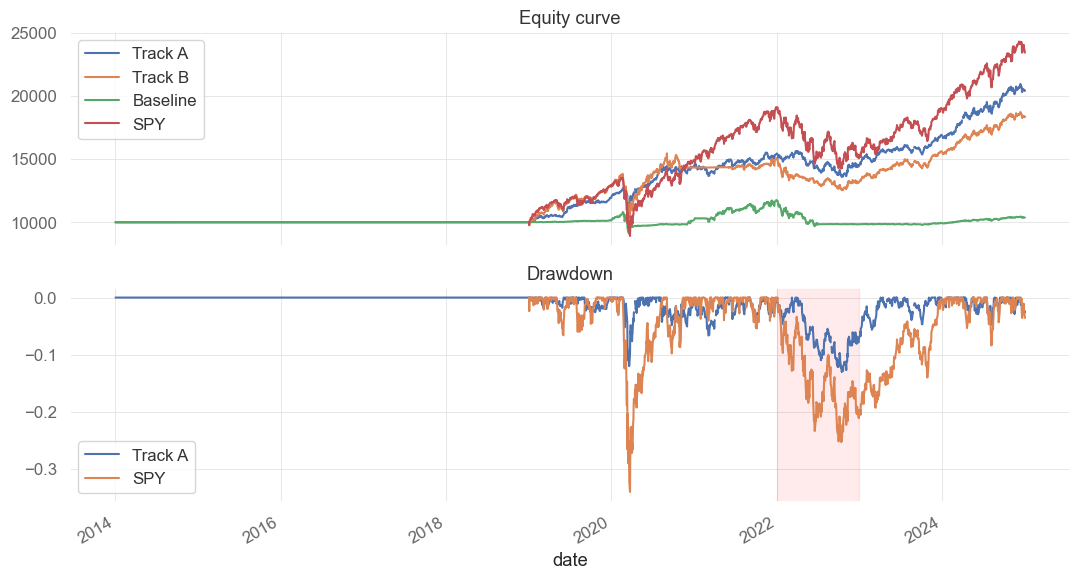

In [8]:
fig, axes = plt.subplots(2, 1, figsize=(11, 6), sharex=True)
pd.DataFrame({"Track A": pf.value(), "Track B": trackb_eq, "Baseline": base_eq, "SPY": spy_bh.value()}).plot(ax=axes[0], grid=True, title="Equity curve")
pd.DataFrame({"Track A": pf.drawdown(), "SPY": spy_bh.drawdown()}).plot(ax=axes[1], grid=True, title="Drawdown")
axes[1].axvspan(pd.Timestamp("2022-01-01"), pd.Timestamp("2022-12-31"), color="red", alpha=0.08)
fig.tight_layout();

## 7. Persist

In [9]:
data_dir = Path.cwd().parent / "data"
tgt.to_parquet(data_dir / "track_a_targets_2019_2024.parquet")
pf.value().to_frame("value").to_parquet(data_dir / "track_a_equity_2019_2024.parquet")
# agent log (views + reasoning) → json so downstream nb 10 can read the rationales
log_serializable = {
    "macro_state": {str(k): v for k, v in log["macro_state"].items()},
    "views":       {str(k): v for k, v in log["views"].items()},
    "reasoning":   {str(k): v for k, v in log["reasoning"].items()},
    "weights":     {str(k): v for k, v in log["weights"].items()},
}
(data_dir / "track_a_agent_log.json").write_text(json.dumps(log_serializable, indent=2, default=str))
print("wrote track_a_targets, track_a_equity, track_a_agent_log.json")

wrote track_a_targets, track_a_equity, track_a_agent_log.json
